## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Column names and data types
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check churn distribution
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

## 2. Data Cleaning and Preprocessing

In [3]:
# Check the data types
print(df.dtypes)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
print("\nMissing values after conversion:")
print(df.isnull().sum())

# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Check the new dataset size
print("\nDataset shape after cleaning:", df.shape)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract           

## 3. Saving Cleaned Dataset

In [6]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_telco_churn_data.csv', index=False)

print("Cleaned dataset saved as 'cleaned_telco_churn_data.csv'")

Cleaned dataset saved as 'cleaned_telco_churn_data.csv'


## 4. Key Customer Metrics

In [4]:
# Key Customer Metrics

total_customers = len(df)

churned_customers = (df['Churn'] == 'Yes').sum()
retained_customers = (df['Churn'] == 'No').sum()

churn_rate = (churned_customers / total_customers) * 100
retention_rate = (retained_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate: {:.2f}%".format(churn_rate))
print("Retention Rate: {:.2f}%".format(retention_rate))

Total Customers: 7032
Churned Customers: 1869
Retained Customers: 5163
Churn Rate: 26.58%
Retention Rate: 73.42%


## 5. Churn Analysis by Contract Type

In [8]:
# Churn by Contract Type

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


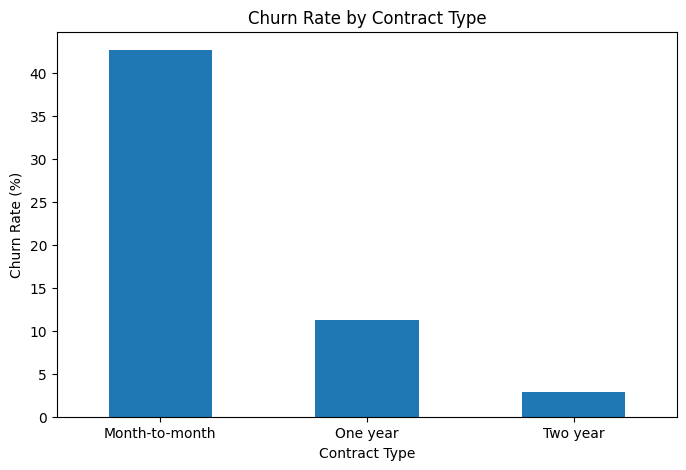

In [9]:
# Visualize churn rate by contract type

contract_churn['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

## 6. Churn Analysis by Tenure Group

In [10]:
# Create customer tenure groups

bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61-72 Months']

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Display the groups
print(df['TenureGroup'].value_counts().sort_index())

TenureGroup
0-12 Months     2175
13-24 Months    1024
25-48 Months    1594
49-60 Months     832
61-72 Months    1407
Name: count, dtype: int64


In [11]:
# Calculate churn rate by tenure group

tenure_churn = (
    df.groupby('TenureGroup', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(tenure_churn)

TenureGroup
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-60 Months    14.423077
61-72 Months     6.609808
Name: Churn, dtype: float64


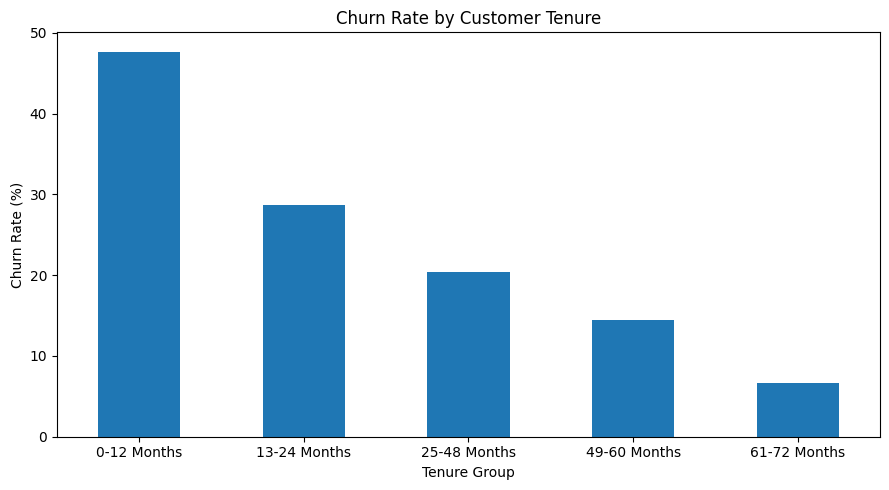

In [12]:
# Visualize churn rate by tenure group

plt.figure(figsize=(9, 5))

tenure_churn.plot(kind='bar')

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Churn Analysis by Payment Method

In [ ]:
# Churn rate by payment method

payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn)

## 8. Visualize churn rate by payment method

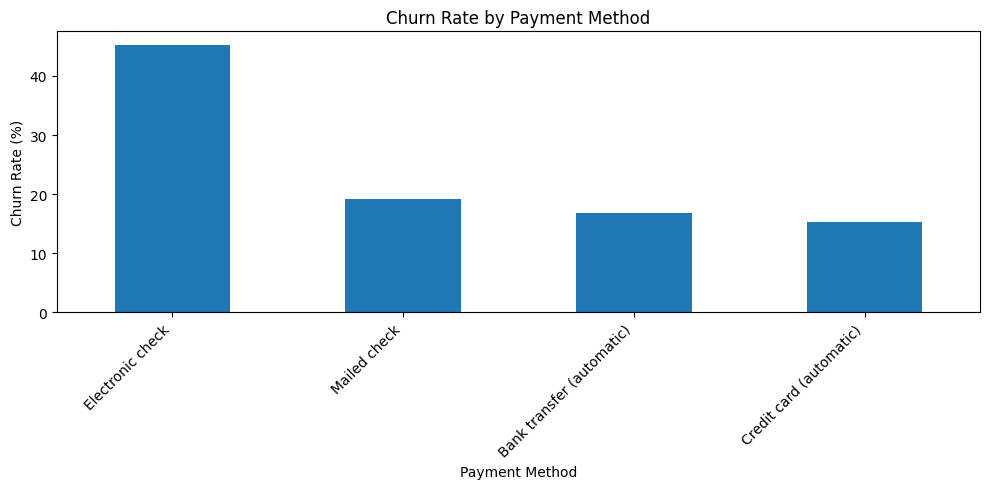

In [14]:
# Visualize churn rate by payment method

plt.figure(figsize=(10, 5))

payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Monthly Charges and Churn Status

In [15]:
# Compare monthly charges by churn status

charges_comparison = df.groupby('Churn')['MonthlyCharges'].agg(
    ['mean', 'median', 'min', 'max']
)

print(charges_comparison)

            mean  median    min     max
Churn                                  
No     61.307408   64.45  18.25  118.75
Yes    74.441332   79.65  18.85  118.35


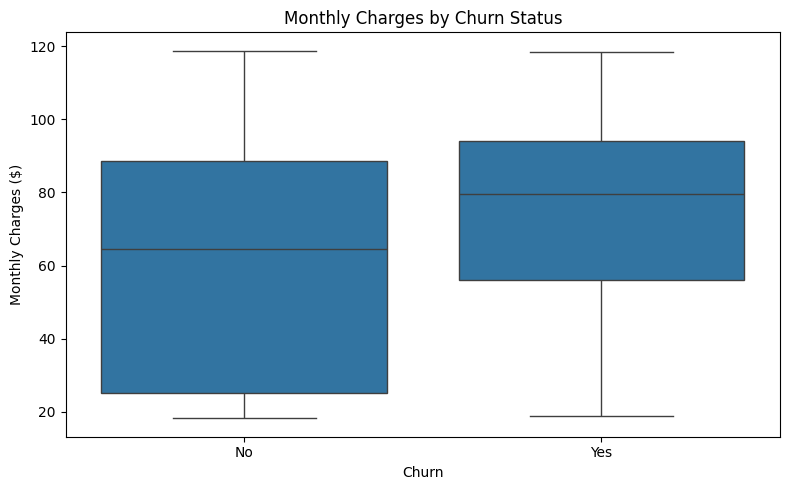

In [16]:
# Box plot of monthly charges by churn

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

## 10. Churn Analysis by Internet Service

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64


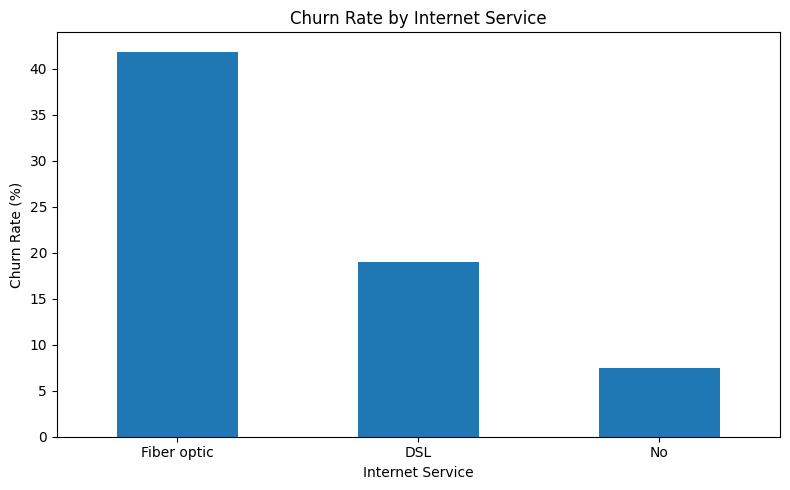

In [17]:
# Churn rate by internet service

internet_churn = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn)

# Plot the results
plt.figure(figsize=(8, 5))

internet_churn.plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Customer Lifetime Analysis

In [18]:

# Customer lifetime analysis

lifetime = df.groupby('Churn')['tenure'].agg(
    ['mean', 'median', 'min', 'max']
)

print("Customer Lifetime by Churn Status:")
print(lifetime)

# Average tenure
avg_lifetime = df['tenure'].mean()
print(f"\nOverall Average Tenure: {avg_lifetime:.2f} months")

Customer Lifetime by Churn Status:
            mean  median  min  max
Churn                             
No     37.650010    38.0    1   72
Yes    17.979133    10.0    1   72

Overall Average Tenure: 32.42 months


## 12. Customer Retention Distribution

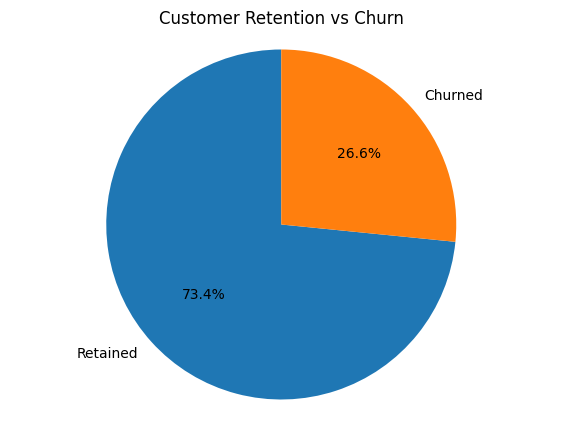

In [19]:

# Customer retention distribution

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(
    churn_counts,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Retention vs Churn')
plt.axis('equal')
plt.show()

## 13. Customer Churn & Retention Dashboard

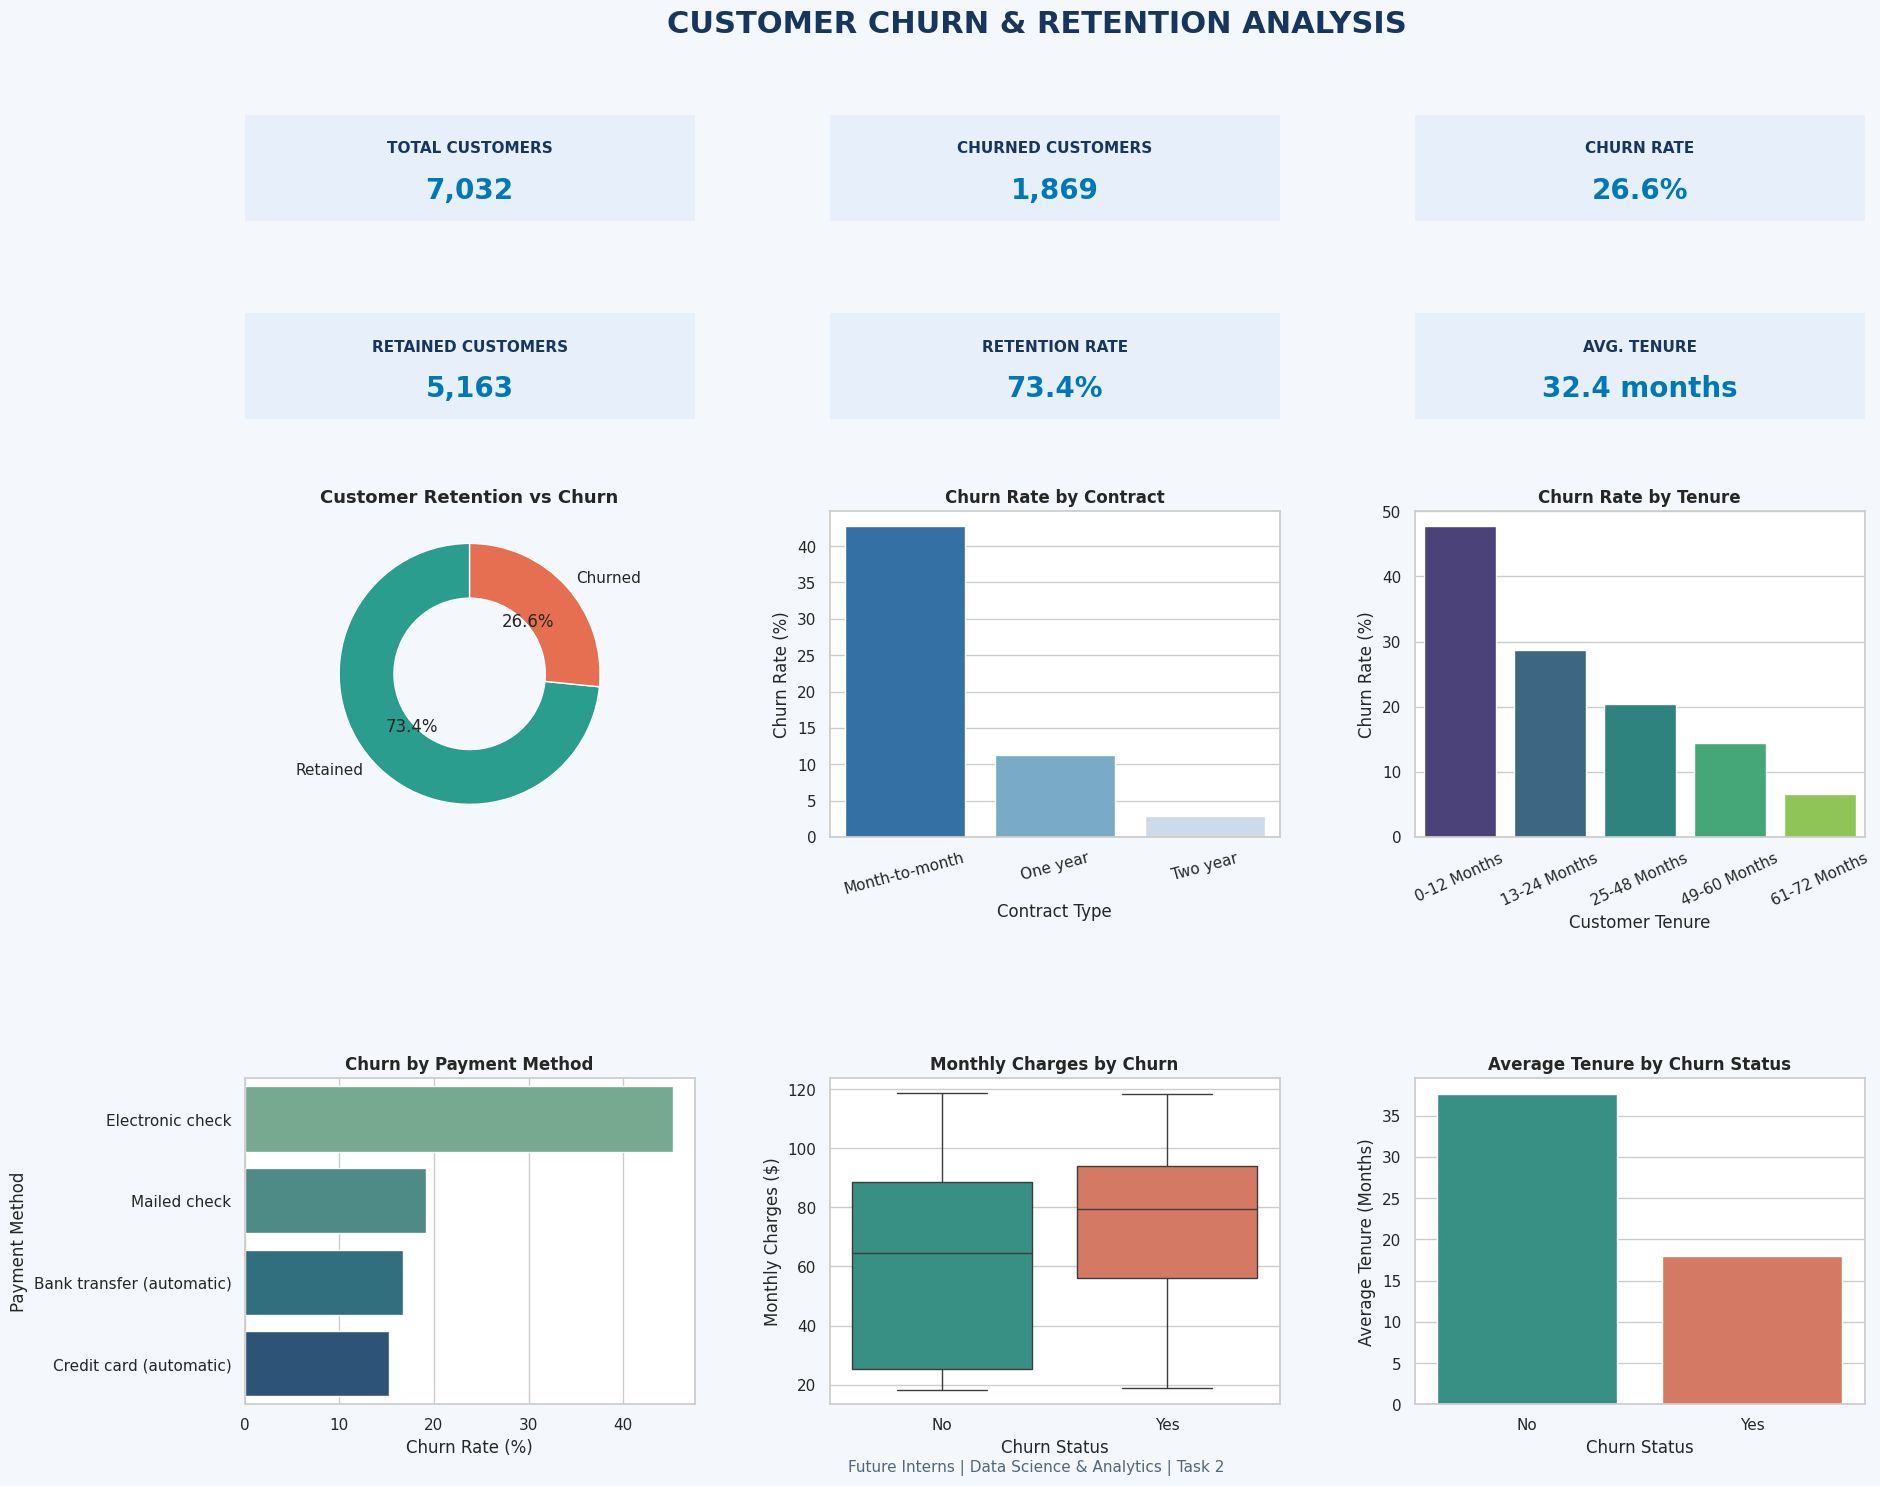

Dashboard created and saved successfully!


In [3]:
# FUTURE INTERNS - TASK 2
# Customer Churn & Retention Dashboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dashboard style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "#f4f7fb"
plt.rcParams["axes.facecolor"] = "white"

# Re-define df and apply necessary preprocessing to ensure it's available
# This section is added to resolve the NameError if previous cells defining df were not run.
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61-72 Months']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# Calculate KPIs
total_customers = len(df)
churned = (df["Churn"] == "Yes").sum()
retained = (df["Churn"] == "No").sum()
churn_rate = churned / total_customers * 100
retention_rate = retained / total_customers * 100
avg_tenure = df["tenure"].mean()

# Calculate churn percentages
contract_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

tenure_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

payment_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

# Create dashboard canvas
fig = plt.figure(figsize=(18, 15))
fig.suptitle(
    "CUSTOMER CHURN & RETENTION ANALYSIS",
    fontsize=22, fontweight="bold", color="#17365d", y=0.98
)

gs = fig.add_gridspec(
    4, 3,
    height_ratios=[0.8, 2, 2, 2],
    hspace=0.45, wspace=0.3,
    top=0.92, bottom=0.06,
    left=0.06, right=0.96
)

# KPI cards
kpis = [
    ("TOTAL CUSTOMERS", f"{total_customers:,}"),
    ("CHURNED CUSTOMERS", f"{churned:,}"),
    ("CHURN RATE", f"{churn_rate:.1f}%"),
    ("RETAINED CUSTOMERS", f"{retained:,}"),
    ("RETENTION RATE", f"{retention_rate:.1f}%"),
    ("AVG. TENURE", f"{avg_tenure:.1f} months")
]

for i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i % 3]) if i < 3 else None

# Use two KPI rows in the first two dashboard rows
# Remove initial temporary axes and rebuild the layout
for ax in fig.axes:
    ax.remove()

gs = fig.add_gridspec(
    5, 3,
    height_ratios=[0.65, 0.65, 2, 0.35, 2],
    hspace=0.5, wspace=0.3,
    top=0.91, bottom=0.05,
    left=0.06, right=0.96
)

for i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.set_facecolor("#e6effa")
    ax.text(0.5, 0.68, label, ha="center", va="center",
            fontsize=11, fontweight="bold", color="#17365d",
            transform=ax.transAxes)
    ax.text(0.5, 0.28, value, ha="center", va="center",
            fontsize=20, fontweight="bold", color="#0077b6",
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Chart 1: Churn distribution
ax1 = fig.add_subplot(gs[2, 0])
ax1.pie(
    [retained, churned],
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2a9d8f", "#e76f51"],
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)
ax1.set_title("Customer Retention vs Churn",
              fontsize=13, fontweight="bold")

# Chart 2: Churn by contract
ax2 = fig.add_subplot(gs[2, 1])
sns.barplot(x=contract_rate.index, y=contract_rate.values,
            hue=contract_rate.index, palette="Blues_r",
            legend=False, ax=ax2)
ax2.set_title("Churn Rate by Contract", fontweight="bold")
ax2.set_xlabel("Contract Type")
ax2.set_ylabel("Churn Rate (%)")
ax2.tick_params(axis="x", rotation=15)

# Chart 3: Churn by tenure
ax3 = fig.add_subplot(gs[2, 2])
sns.barplot(x=tenure_rate.index.astype(str),
            y=tenure_rate.values,
            hue=tenure_rate.index.astype(str),
            palette="viridis", legend=False, ax=ax3)
ax3.set_title("Churn Rate by Tenure", fontweight="bold")
ax3.set_xlabel("Customer Tenure")
ax3.set_ylabel("Churn Rate (%)")
ax3.tick_params(axis="x", rotation=25)

# Chart 4: Churn by payment method
ax4 = fig.add_subplot(gs[4, 0])
sns.barplot(x=payment_rate.values, y=payment_rate.index,
            hue=payment_rate.index, palette="crest",
            legend=False, ax=ax4)
ax4.set_title("Churn by Payment Method", fontweight="bold")
ax4.set_xlabel("Churn Rate (%)")
ax4.set_ylabel("Payment Method")

# Chart 5: Monthly charges by churn status
ax5 = fig.add_subplot(gs[4, 1])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges",
            hue="Churn", palette={"No": "#2a9d8f",
                                  "Yes": "#e76f51"},
            legend=False, ax=ax5)
ax5.set_title("Monthly Charges by Churn", fontweight="bold")
ax5.set_xlabel("Churn Status")
ax5.set_ylabel("Monthly Charges ($)")

# Chart 6: Average tenure by churn status
ax6 = fig.add_subplot(gs[4, 2])
avg_tenure_churn = df.groupby("Churn")["tenure"].mean()
sns.barplot(x=avg_tenure_churn.index,
            y=avg_tenure_churn.values,
            hue=avg_tenure_churn.index,
            palette={"No": "#2a9d8f", "Yes": "#e76f51"},
            legend=False, ax=ax6)
ax6.set_title("Average Tenure by Churn Status", fontweight="bold")
ax6.set_xlabel("Churn Status")
ax6.set_ylabel("Average Tenure (Months)")

# Add footer
fig.text(
    0.5, 0.005,
    "Future Interns | Data Science & Analytics | Task 2",
    ha="center", fontsize=11, color="#52677d"
)

plt.savefig("FUTURE_DS_02_Dashboard.png",
            dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

print("Dashboard created and saved successfully!")